<a href="https://colab.research.google.com/github/SumukhaSrivatsa-BSC/BSC_AI_Training/blob/main/06-07-2026/06_07_2026_Web_Scraping_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import logging

for handler in logging.root.handlers[:]:
  logging.root.removeHandler(handler)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s|%(levelname)s|%(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    force=True
)
logging.info("Application started successfully")

2026-07-06 04:16:45|INFO|Application started successfully


In [ ]:
data = {
"Experience": [1, 2, 3, 4, 5, 6],
"Salary": [25000, 30000, 40000, 50000, 60000, 70000]
}

df = pd. DataFrame (data)
logging.info(f"Dataset Shape : {df.shape}")

2026-07-06 04:23:08|INFO|Dataset Shape : (6, 2)


In [ ]:
X = df[['Experience']]
y = df['Salary']

model = LinearRegression ()
model.fit(X, y)

logging.info(f"Intercept : {model.intercept_}")
logging.info(f"Coefficient : {model.coef_[0]}")

# Predict for a new experience level (e.g., 7 years)
new_experience = pd.DataFrame([7], columns=['Experience'])
prediction = model.predict(new_experience)
logging.info("Prediction Completed Successfully")
print ("Predicted Salary =", prediction [0])

logging.info("Application Finished Successfully")

2026-07-06 04:28:02|INFO|Intercept : 13333.333333333336
2026-07-06 04:28:02|INFO|Coefficient : 9285.714285714286
2026-07-06 04:28:02|INFO|Prediction Completed Successfully
2026-07-06 04:28:02|INFO|Application Finished Successfully


Predicted Salary = 78333.33333333334


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
url = "https://books.toscrape.com/"
response = requests.get(url)
print("Status Code :", response.status_code)
soup = BeautifulSoup(response.text, "html.parser")
books = soup.find_all("article", class_="product_pod")
print("Total Books :", len(books))

Status Code : 200
Total Books : 20


In [ ]:
print(response.text)

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
        <meta name="created" content="24th Jun 2016 09:29" />
        <meta name="description" content="" />
        <meta name="viewport" content="width=device-width" />
        <meta name="robots" content="NOARCHIVE,NOCACHE" />

        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
        <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->

        
            <link rel="shortcut icon" href="static/oscar/favicon.

In [ ]:
book_name = []
price = []
rating = []
availability = []

for book in books:
  # Book Name
  name = book.h3.a["title"]
  # Price
  cost = book.find("p", class_="price_color").text
  # Rating (e.g. "star-rating Three")
  stars = book.find("p")["class"][1]
  # Availability
  stock = book.find("p", class_="instock availability").text.strip()

  book_name.append(name)
  price.append(cost)
  rating.append(stars)
  availability.append(stock)

Web Scraping Project

In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

url = "https://realpython.github.io/fake-jobs/"

response = requests.get(url)

print("Status Code:", response.status_code)

soup = BeautifulSoup(response.text, "html.parser")

jobs = soup.find_all("div", class_="card-content")

data = []

for job in jobs:

    title = job.find("h2", class_="title").text.strip()

    company = job.find("h3", class_="company").text.strip()

    location = job.find("p", class_="location").text.strip()

    apply_link = job.find_all("a")[1]["href"]

    data.append({
        "Job Title": title,
        "Company Name": company,
        "Skills": "Not Available",
        "Salary": "Not Available",
        "Location": location,
        "Posting Date": "Not Available",
        "Apply Link": apply_link
    })

df = pd.DataFrame(data)

print(df)

df.to_csv("jobs.csv", index=False)

print("CSV Saved Successfully")

Status Code: 200
                             Job Title                Company Name  \
0              Senior Python Developer    Payne, Roberts and Davis   
1                      Energy engineer            Vasquez-Davidson   
2                      Legal executive  Jackson, Chambers and Levy   
3               Fitness centre manager              Savage-Bradley   
4                      Product manager                 Ramirez Inc   
..                                 ...                         ...   
95  Museum/gallery exhibitions officer     Nguyen, Yoder and Petty   
96            Radiographer, diagnostic                  Holder LLC   
97              Database administrator              Yates-Ferguson   
98                  Furniture designer             Ortega-Lawrence   
99                         Ship broker   Fuentes, Walls and Castro   

           Skills         Salary              Location   Posting Date  \
0   Not Available  Not Available       Stewartbury, AA  Not Available

In [ ]:
df.head()


,Job Title,Company Name,Skills,Salary,Location,Posting Date,Apply Link
0,Senior Python Developer,"Payne, Roberts and Davis",Not Available,Not Available,"Stewartbury, AA",Not Available,https://realpython.github.io/fake-jobs/jobs/se...
1,Energy engineer,Vasquez-Davidson,Not Available,Not Available,"Christopherville, AA",Not Available,https://realpython.github.io/fake-jobs/jobs/en...
2,Legal executive,"Jackson, Chambers and Levy",Not Available,Not Available,"Port Ericaburgh, AA",Not Available,https://realpython.github.io/fake-jobs/jobs/le...
3,Fitness centre manager,Savage-Bradley,Not Available,Not Available,"East Seanview, AP",Not Available,https://realpython.github.io/fake-jobs/jobs/fi...
4,Product manager,Ramirez Inc,Not Available,Not Available,"North Jamieview, AP",Not Available,https://realpython.github.io/fake-jobs/jobs/pr...


In [ ]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(100, 7)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Job Title     100 non-null    object
 1   Company Name  100 non-null    object
 2   Skills        100 non-null    object
 3   Salary        100 non-null    object
 4   Location      100 non-null    object
 5   Posting Date  100 non-null    object
 6   Apply Link    100 non-null    object
dtypes: object(7)
memory usage: 5.6+ KB


In [ ]:
df.isnull().sum()

,0
Job Title,0
Company Name,0
Skills,0
Salary,0
Location,0
Posting Date,0
Apply Link,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe(include="all")

,Job Title,Company Name,Skills,Salary,Location,Posting Date,Apply Link
count,100,100,100,100,100,100,100
unique,92,99,1,1,100,1,100
top,Python Programmer (Entry-Level),Garcia PLC,Not Available,Not Available,"Stewartbury, AA",Not Available,https://realpython.github.io/fake-jobs/jobs/se...
freq,3,2,100,100,1,100,1


In [ ]:
company_count = df["Company Name"].value_counts()

print(company_count.head(10))

Company Name
Garcia PLC                    2
Vasquez-Davidson              1
Payne, Roberts and Davis      1
Jackson, Chambers and Levy    1
Savage-Bradley                1
Rogers-Yates                  1
Ramirez Inc                   1
Kramer-Klein                  1
Meyers-Johnson                1
Hughes-Williams               1
Name: count, dtype: int64


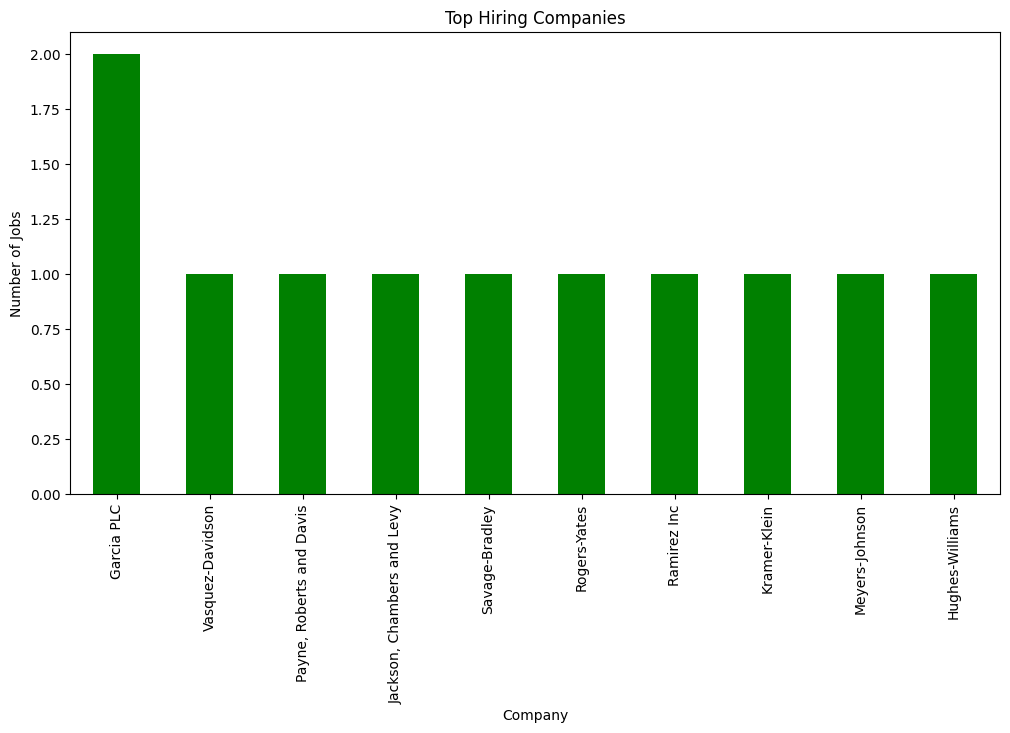

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

company_count.head(10).plot(
    kind="bar",
    color="green"
)

plt.title("Top Hiring Companies")

plt.xlabel("Company")

plt.ylabel("Number of Jobs")

plt.show()

In [ ]:
location_count = df["Location"].value_counts()

print(location_count.head(10))

Location
Stewartbury, AA          1
Christopherville, AA     1
Port Ericaburgh, AA      1
East Seanview, AP        1
North Jamieview, AP      1
Davidville, AP           1
South Christopher, AE    1
Port Jonathan, AE        1
Osbornetown, AE          1
Scotttown, AP            1
Name: count, dtype: int64


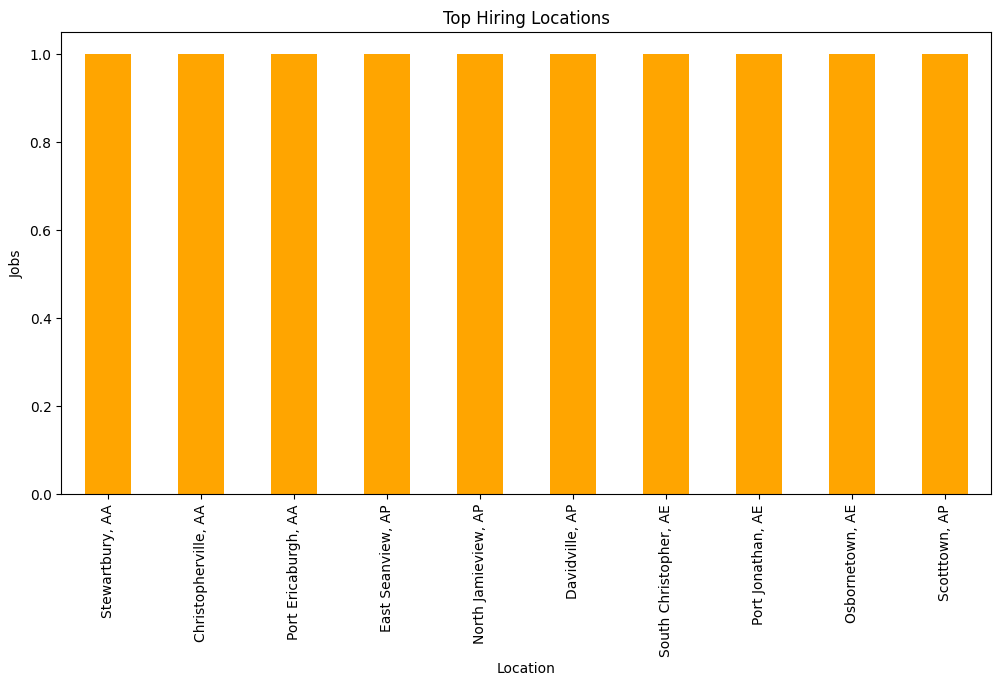

In [ ]:
plt.figure(figsize=(12,6))

location_count.head(10).plot(
    kind="bar",
    color="orange"
)

plt.title("Top Hiring Locations")

plt.xlabel("Location")

plt.ylabel("Jobs")

plt.show()

In [ ]:
print(
    "Total Jobs Collected:",
    len(df)
)

Total Jobs Collected: 100


In [ ]:
print(
    "Total Companies:",
    df["Company Name"].nunique()
)

Total Companies: 99


In [ ]:
print(
    "Total Locations:",
    df["Location"].nunique()
)

Total Locations: 100


In [ ]:
df_clean = df.copy()

df_clean.to_csv(
    "jobs_clean.csv",
    index=False
)

In [ ]:
df_clean.to_excel(
    "jobs_clean.xlsx",
    index=False
)

In [ ]:
print("PROJECT INSIGHTS")
print("-"*50)

print(
    "Total Jobs:",
    len(df)
)

print(
    "Top Company:",
    df["Company Name"].mode()[0]
)

print(
    "Top Location:",
    df["Location"].mode()[0]
)

print(
    "Unique Companies:",
    df["Company Name"].nunique()
)

PROJECT INSIGHTS
--------------------------------------------------
Total Jobs: 100
Top Company: Garcia PLC
Top Location: Adamburgh, AA
Unique Companies: 99


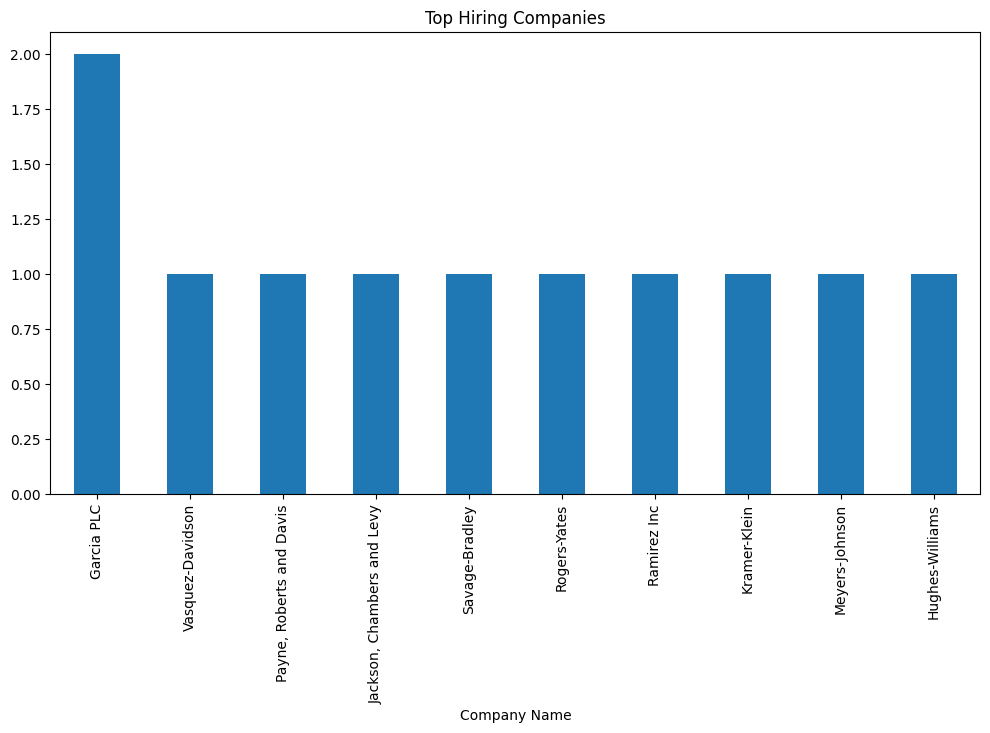

In [ ]:
plt.figure(figsize=(12,6))

company_count.head(10).plot(kind='bar')

plt.title("Top Hiring Companies")

plt.savefig("top_companies.png")

plt.show()

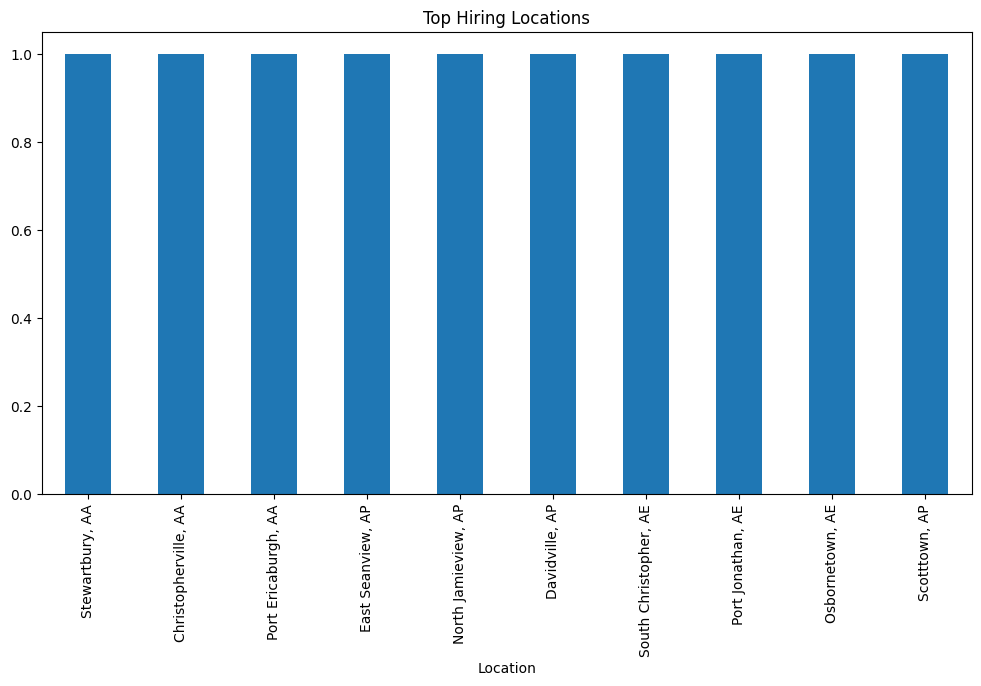

In [ ]:
plt.figure(figsize=(12,6))

location_count.head(10).plot(kind='bar')

plt.title("Top Hiring Locations")

plt.savefig("top_locations.png")

plt.show()